In [3]:
#importing libraries
import numpy as np
import random
import matplotlib
import matplotlib.pyplot as plt

In [4]:
#configuring the graph display
is_ipython = 'inline' in matplotlib.get_backend()
if is_ipython: 
    from IPython import display

In [15]:
iterations = 100000

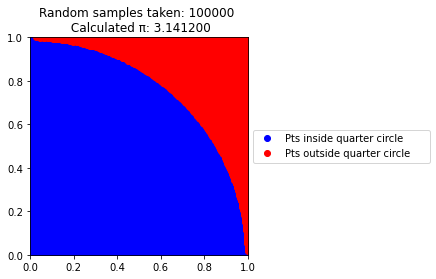

In [16]:
# List for storing the X,Y coordinates of points generated from uniform (0,1) distribution
Piq = [ [], [] ]  #Points Inside Quarter-circle   [ [x1,x2,x3,x5...], [y1,y2,y3,y5...]]
Poq = [ [], [] ]  #Points Outside Quarter-circle  [ [x4,x5,x7,x8...], [y4,y5,y7,y8...]]
Approx_pi = list()
count = 0

# For Drawing the Quarter-circle
theta = np.linspace( 0 , 0.5 * np.pi , 100 ) 
cx = 1 * np.cos(theta)  # x = R cos(theta)
cy = 1 * np.sin(theta)  # y = R sin(theta)

for n in range(1, iterations+1):
    px = np.random.uniform(0, 1)
    py = np.random.uniform(0, 1)
    
    dist = np.sqrt(np.power(px,2) + np.power(py,2))
    
    if dist < 1.0: #True means pt lies inside quarter-circle
        count += 1
    
        Piq[0].append(px)
        Piq[1].append(py)
    else:
        Poq[0].append(px)
        Poq[1].append(py)
    
    approx_pi = 4.0*count/n     #Calculating the value of Pi
    Approx_pi.append(approx_pi) 
    
    # To get only the final output plotted, make the below plotting statements outside the loop
    #Plotting
    plt.clf()
    plt.axis('scaled')

    plt.xlim(0,1)
    plt.ylim(0,1)
    plt.plot(cx,cy)
    plt.title("Random samples taken: %d \n Calculated π: %f"  %(n,approx_pi) )

    plt.gca().plot(Piq[0],Piq[1],'bo', label = 'Pts inside quarter circle     ')
    plt.gca().plot(Poq[0],Poq[1],'ro', label = 'Pts outside quarter circle     ')

    if is_ipython: 
        display.clear_output(wait=True)   # Make it false for quick execution

    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    #For saving the output, after every new 5 samples
    #if n%5 == 0:
    #    plt.tight_layout()
    #    plt.savefig('%d Samples done, Approx Pi is %f.jpg' %(n,approx_pi))

    plt.show()                            # Comment out, to disable plotting every iteration 
plt.show()

In [ ]:
#Saving files Working

In [ ]:
'''
# Test Example
np.save('test3.npy', a)    # .npy extension is added if not given
d = np.load('test3.npy')
a == d
# array([ True,  True,  True,  True], dtype=bool)
'''

In [7]:
np.save('piq_np.npy', Piq)
np.save('poq_np.npy', Poq)
np.save('Approx_pi_np.npy', Approx_pi)

In [8]:
#####################

In [9]:
piq = np.load('piq_np.npy')
poq = np.load('poq_np.npy')
approx_pi_list = np.load('Approx_pi_np.npy')

In [10]:
# Plotting Graphs

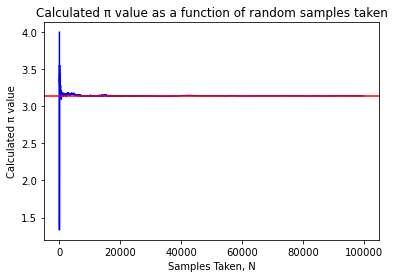

In [17]:
plt.plot(Approx_pi,color = 'b', label = 'Calculated π value')
plt.gca().axhline(y=np.pi, c = 'r', label = 'Actual π value, 3.141592')

plt.xlabel("Samples Taken, N")
plt.ylabel("Calculated π value")
plt.title("Calculated π value as a function of random samples taken")

plt.savefig('Pi value change graph %d Samples done, Approx Pi is %f.jpg' %(n,approx_pi))
plt.show()

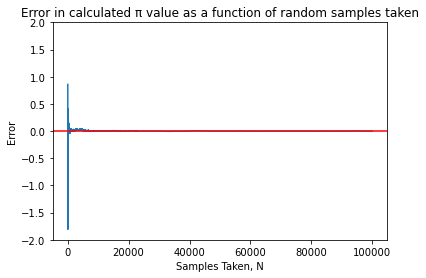

In [18]:
plt.plot((np.array(Approx_pi)-np.pi), label = "Error in π value estimation")
plt.gca().axhline(y=0, c = 'r', label = 'Zero error line')

plt.xlabel("Samples Taken, N")
plt.ylabel("Error")
plt.ylim(-2,2)
plt.title("Error in calculated π value as a function of random samples taken")

plt.savefig('Error graph %d Samples done, Approx Pi is %f.jpg' %(n,approx_pi))
plt.show()